# Transfermarkt Football Time Series Analysis

## Time Series Analysis Version 1: Exponential Smoothing and Linear Regression

In [1]:
%pip install statsmodels
%pip install matplotlib

import pandas as pd
import numpy as np
import re
from pathlib import Path
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# -----------------------------
# CONFIG
# -----------------------------
FILES = [
    "transfermarkt data/Historical Data/historical_gk_mv.csv",
    "transfermarkt data/Historical Data/historical_defender_mv.csv",
    "transfermarkt data/Historical Data/historical_midfielder_mv.csv",
    "transfermarkt data/Historical Data/historical_forward_mv.csv"
]

FORECAST_HORIZON_MONTHS = 60
OUTPUT_FORECAST_FILE = "player_market_value_forecasts_5y.csv"
OUTPUT_METRICS_FILE = "player_model_metrics.csv"

# Current month/year from "now"
CURRENT_MONTH_START = pd.Timestamp.today().to_period("M").to_timestamp()

In [3]:
# -----------------------------
# HELPERS
# -----------------------------
def parse_market_value_text(val):
    """
    Convert Transfermarkt-style text values like:
      '€30.00m', '€750k', '€1.2bn'
    into numeric euros.
    """
    if pd.isna(val):
        return np.nan
    
    s = str(val).strip().lower()
    s = s.replace("€", "").replace(",", "").strip()

    match = re.match(r"([0-9]*\.?[0-9]+)\s*([a-z]+)?", s)
    if not match:
        return np.nan
    
    num = float(match.group(1))
    suffix = match.group(2)

    if suffix == "k":
        return num * 1_000
    elif suffix == "m":
        return num * 1_000_000
    elif suffix == "bn":
        return num * 1_000_000_000
    elif suffix is None:
        return num
    else:
        return np.nan


def clean_market_value_column(df):
    """
    Use numeric 'Market Value' if available; otherwise parse 'Market Value (text)'.
    """
    df = df.copy()

    if "Market Value" in df.columns:
        df["Market Value"] = pd.to_numeric(df["Market Value"], errors="coerce")
    else:
        df["Market Value"] = np.nan

    if "Market Value (text)" in df.columns:
        parsed = df["Market Value (text)"].apply(parse_market_value_text)
        df["Market Value"] = df["Market Value"].fillna(parsed)

    return df


def load_all_data(files):
    dfs = []
    for file in files:
        df = pd.read_csv(file)
        df["source_file"] = Path(file).stem
        dfs.append(df)
    full = pd.concat(dfs, ignore_index=True)
    return full


def prepare_player_monthly_series(player_df, current_month_start):
    """
    Convert irregular value-change observations into a regular monthly series.

    Steps:
    - sort by date
    - keep latest observation within each month
    - reindex to monthly frequency
    - forward fill values between known updates
    """
    df = player_df.copy()

    # Ensure dates are parsed
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date", "Market Value"])
    df = df.sort_values("Date")

    if df.empty:
        return None

    # Month bucket
    df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

    # Keep latest observation in each month
    monthly = df.groupby("Month", as_index=True).last()

    # Build full monthly index from first observed month to current month
    start_month = monthly.index.min()
    end_month = max(monthly.index.max(), current_month_start)

    monthly = monthly.reindex(pd.date_range(start=start_month, end=end_month, freq="MS"))

    # Forward fill market value, team, age, player metadata
    monthly["Market Value"] = monthly["Market Value"].ffill()
    for col in ["Player", "Team", "Age", "Year", "source_file"]:
        if col in monthly.columns:
            monthly[col] = monthly[col].ffill()

    # Drop leading NaNs if any remain
    monthly = monthly.dropna(subset=["Market Value"])

    # allow one-month series to still be forecasted via linear fallback
    if len(monthly) < 1:
        return None

    return monthly


def time_split_backtest(y, holdout=12):
    """
    Last `holdout` months as test if enough history exists.
    """
    if len(y) < holdout + 12:
        return None, None
    return y.iloc[:-holdout], y.iloc[-holdout:]


def fit_exponential_smoothing(train_log):
    """
    Damped trend model on log-transformed market value.
    """
    model = ExponentialSmoothing(
        train_log,
        trend="add",
        damped_trend=True,
        seasonal=None,
        initialization_method="estimated"
    )
    fitted = model.fit(optimized=True, use_brute=True)
    return fitted


def fit_linear_regression(train_log):
    """
    Simple fallback linear trend on log market value.
    """
    X = np.arange(len(train_log)).reshape(-1, 1)
    y = train_log.values
    lr = LinearRegression()
    lr.fit(X, y)
    return lr


def predict_linear_regression(model, start_idx, steps):
    X_future = np.arange(start_idx, start_idx + steps).reshape(-1, 1)
    return model.predict(X_future)


def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


def plot_player_forecast(player_name, raw_df, forecast_df):
    hist = raw_df[raw_df["Player"] == player_name].copy()
    hist["Date"] = pd.to_datetime(hist["Date"], errors="coerce")
    hist = hist.dropna(subset=["Date", "Market Value"]).sort_values("Date")

    fc = forecast_df[forecast_df["Player"] == player_name].copy()

    plt.figure(figsize=(10, 5))
    plt.plot(hist["Date"], hist["Market Value"], label="Historical")
    plt.plot(fc["Forecast Date"], fc["Predicted Market Value"], label="Forecast")
    plt.title(f"{player_name} Market Value Forecast")
    plt.xlabel("Date")
    plt.ylabel("Market Value")
    plt.legend()
    plt.tight_layout()
    plt.show()


def model_player_series(monthly, forecast_horizon=60):
    """
    Fit per-player model, evaluate if possible, and forecast future months.
    """
    y = monthly["Market Value"].astype(float).copy()

    # Avoid zeros in log transform
    y = y.clip(lower=1.0)
    y_log = np.log1p(y)

    train_log, test_log = time_split_backtest(y_log, holdout=12)

    model_name = None
    metric_row = {
        "Player": monthly["Player"].dropna().iloc[-1] if "Player" in monthly.columns else None,
        "n_months": len(y),
        "model": None,
        "test_smape": np.nan,
        "test_mae": np.nan
    }

    # Choose model
    try:
        if len(y) >= 24:
            # Use train if backtesting exists, else full data
            train_for_fit = train_log if train_log is not None else y_log
            fitted = fit_exponential_smoothing(train_for_fit)
            model_name = "ETS_damped_trend"

            # Backtest
            if test_log is not None:
                pred_log = fitted.forecast(len(test_log))
                pred = np.expm1(pred_log).clip(lower=0)
                actual = np.expm1(test_log)
                metric_row["test_smape"] = smape(actual.values, pred.values)
                metric_row["test_mae"] = np.mean(np.abs(actual.values - pred.values))

            # Refit on full data for final forecast
            fitted_full = fit_exponential_smoothing(y_log)
            future_log = fitted_full.forecast(forecast_horizon)

        else:
            raise ValueError("Too short for ETS")

    except Exception:
        # Fallback to linear regression on log values
        model_name = "LinearRegression_log_trend"

        train_for_fit = train_log if train_log is not None else y_log
        lr = fit_linear_regression(train_for_fit)

        if test_log is not None:
            pred_log = predict_linear_regression(lr, len(train_for_fit), len(test_log))
            pred = np.expm1(pred_log).clip(lower=0)
            actual = np.expm1(test_log.values)
            metric_row["test_smape"] = smape(actual, pred)
            metric_row["test_mae"] = np.mean(np.abs(actual - pred))

        lr_full = fit_linear_regression(y_log)
        future_log = predict_linear_regression(lr_full, len(y_log), forecast_horizon)
        future_log = pd.Series(future_log)

    metric_row["model"] = model_name

    future_values = np.expm1(future_log).clip(lower=0, upper=300_000_000)

    # Build forecast dates
    last_month = monthly.index.max()
    forecast_index = pd.date_range(
        start=last_month + pd.offsets.MonthBegin(1),
        periods=forecast_horizon,
        freq="MS"
    )

    # If user specifically wants forecasts from the current month forward,
    # align start to current month if last historical month is behind today.
    start_forecast = max(last_month + pd.offsets.MonthBegin(1), CURRENT_MONTH_START)
    forecast_index = pd.date_range(
        start=start_forecast,
        periods=forecast_horizon,
        freq="MS"
    )

    # Recalculate future values if needed to match horizon only
    future_values = future_values[:forecast_horizon]

    forecast_df = pd.DataFrame({
        "Player": metric_row["Player"],
        "Forecast Date": forecast_index,
        "Predicted Market Value": future_values
    })

    # Optional metadata
    if "Team" in monthly.columns and monthly["Team"].notna().any():
        forecast_df["Last Known Team"] = monthly["Team"].dropna().iloc[-1]
    else:
        forecast_df["Last Known Team"] = np.nan

    if "Age" in monthly.columns and monthly["Age"].notna().any():
        forecast_df["Last Known Age"] = monthly["Age"].dropna().iloc[-1]
    else:
        forecast_df["Last Known Age"] = np.nan

    forecast_df["Model"] = model_name

    return forecast_df, metric_row

In [4]:
# -----------------------------
# MAIN PIPELINE
# -----------------------------
def run_pipeline(files):
    df = load_all_data(files)
    df = clean_market_value_column(df)

    # Keep only needed columns if present
    required_cols = ["Player", "Date", "Market Value"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df.dropna(subset=["Player", "Date", "Market Value"]).copy()

    all_forecasts = []
    all_metrics = []

    players = sorted(df["Player"].dropna().unique())

    for i, player in enumerate(players, start=1):
        player_df = df[df["Player"] == player].copy()
        monthly = prepare_player_monthly_series(player_df, CURRENT_MONTH_START)

        if monthly is None or len(monthly) < 2:
            continue

        try:
            forecast_df, metric_row = model_player_series(
                monthly,
                forecast_horizon=FORECAST_HORIZON_MONTHS
            )
            all_forecasts.append(forecast_df)
            all_metrics.append(metric_row)

            if i % 100 == 0:
                print(f"Processed {i} players...")
        except Exception as e:
            print(f"Skipping {player} error: {e}")

    if not all_forecasts:
        print("No player forecasts were generated; returning empty output tables.")
        forecast_out = pd.DataFrame(
            columns=[
                "Player", "Forecast Date", "Predicted Market Value",
                "Last Known Team", "Last Known Age", "Model"
            ]
        )
        metrics_out = pd.DataFrame(
            columns=["Player", "n_months", "model", "test_smape", "test_mae"]
        )
    else:
        forecast_out = pd.concat(all_forecasts, ignore_index=True)
        metrics_out = pd.DataFrame(all_metrics)

    forecast_out.to_csv(OUTPUT_FORECAST_FILE, index=False)
    metrics_out.to_csv(OUTPUT_METRICS_FILE, index=False)

    return forecast_out, metrics_out

In [5]:
forecasts, metrics = run_pipeline(FILES)
print("\nSaved:")
print(f"  - {OUTPUT_FORECAST_FILE}")
print(f"  - {OUTPUT_METRICS_FILE}")
print("\nSample forecasts:")
print(forecasts.head(10))
print("\nSample metrics:")
print(metrics.head(10))

Processed 100 players...
Processed 200 players...
Processed 300 players...
Processed 400 players...
Processed 500 players...
Processed 600 players...
Processed 700 players...
Processed 800 players...
Processed 900 players...
Processed 1000 players...
Processed 1100 players...
Processed 1200 players...
Processed 1300 players...
Processed 1400 players...
Processed 1500 players...
Processed 1600 players...
Processed 1700 players...

Saved:
  - player_market_value_forecasts_5y.csv
  - player_model_metrics.csv

Sample forecasts:
         Player Forecast Date  Predicted Market Value Last Known Team  \
0  Aaron Hickey    2026-05-01            1.617542e+07    Brentford FC   
1  Aaron Hickey    2026-06-01            1.632689e+07    Brentford FC   
2  Aaron Hickey    2026-07-01            1.647395e+07    Brentford FC   
3  Aaron Hickey    2026-08-01            1.661666e+07    Brentford FC   
4  Aaron Hickey    2026-09-01            1.675512e+07    Brentford FC   
5  Aaron Hickey    2026-10-01   

Plotting forecast for: Aaron Hickey


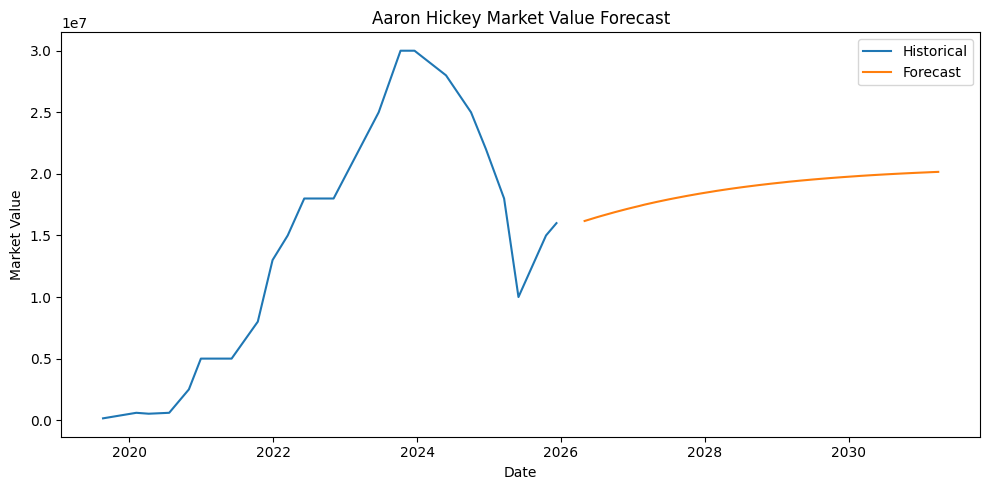

Plotting forecast for: Aaron Ramsdale


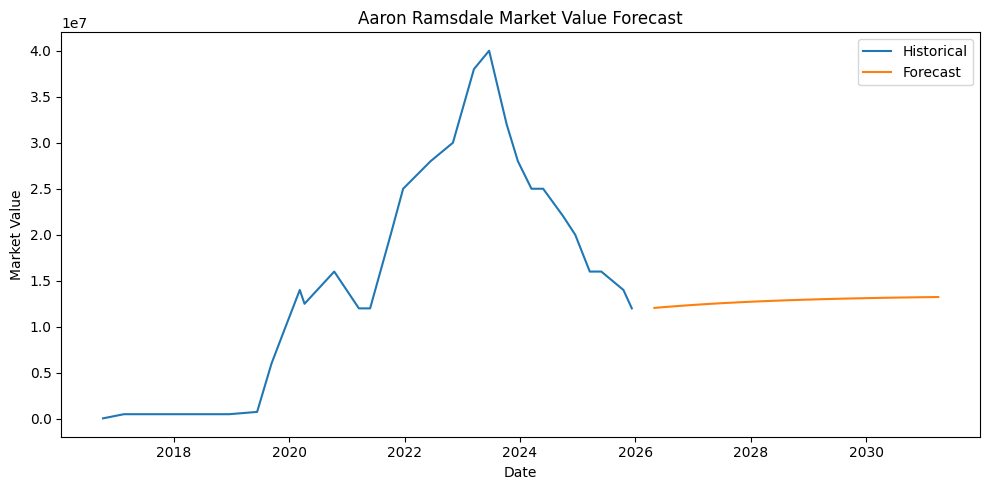

Plotting forecast for: Aaron Ramsey


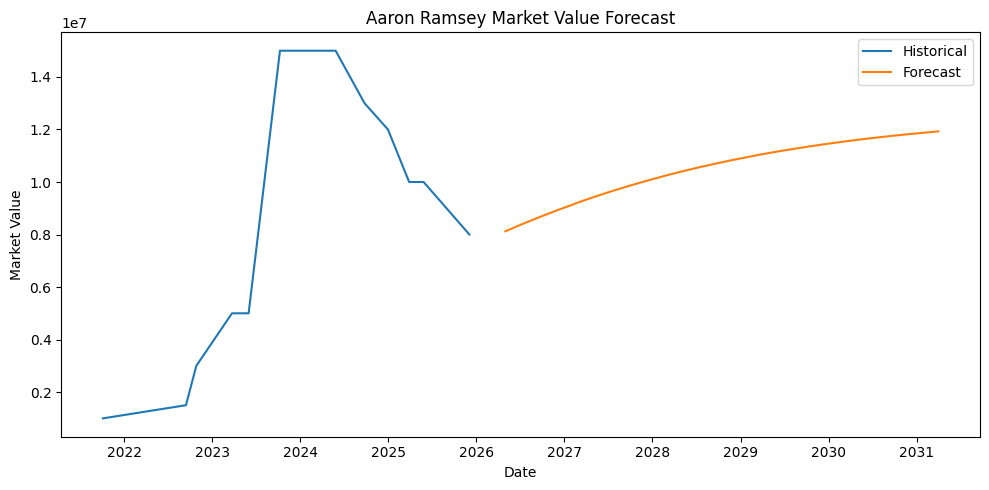

Plotting forecast for: Aaron Wan-Bissaka


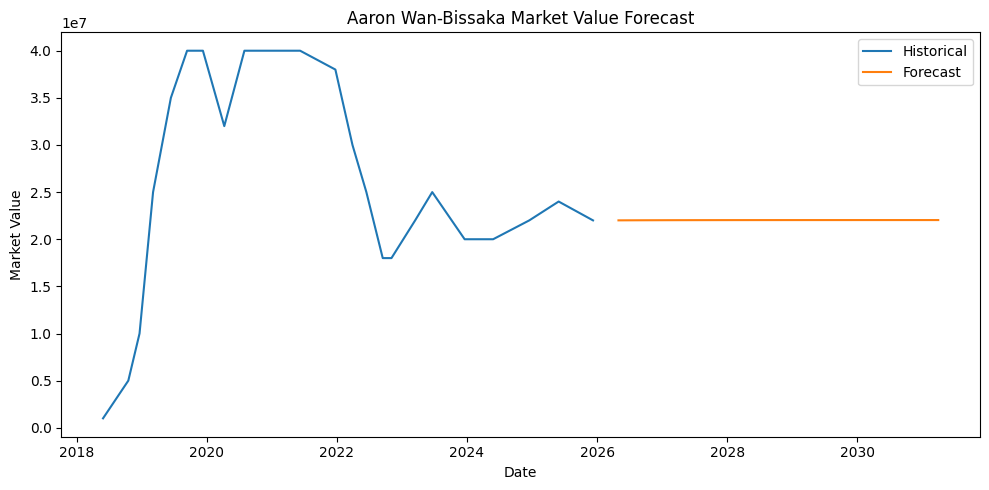

Plotting forecast for: Aarón Anselmino


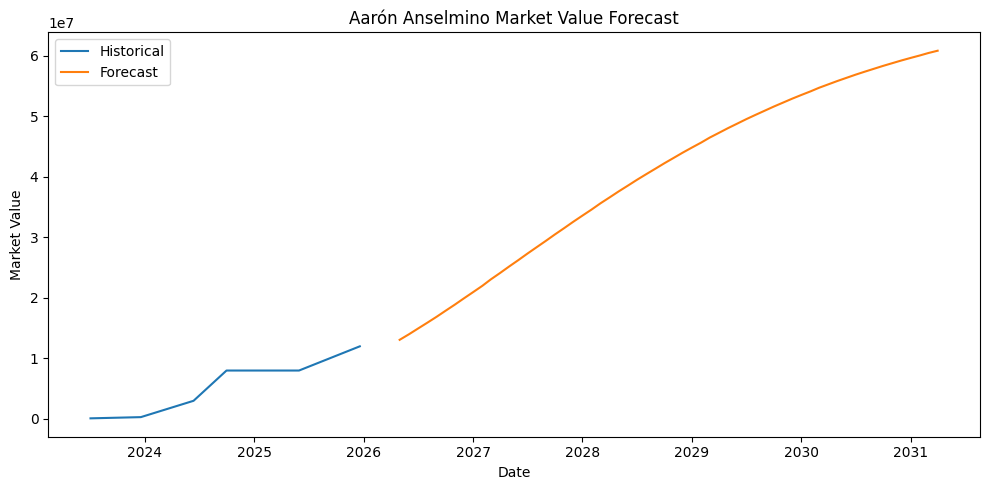

In [6]:
forecast_out = pd.read_csv(OUTPUT_FORECAST_FILE, parse_dates=["Forecast Date"])
raw_df = clean_market_value_column(load_all_data(FILES))

players_to_plot = forecast_out["Player"].dropna().unique()[:5]

for player in players_to_plot:
    print(f"Plotting forecast for: {player}")
    plot_player_forecast(player, raw_df, forecast_out)

## Time Series Analysis Version 2: Ensemble Model (Exponential Smoothing, Linear Regression, SARIMA, Prophet)

### Packages

In [7]:
%pip install prophet
import pandas as pd
import numpy as np
import re
import warnings
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# Prophet import
PROPHET_AVAILABLE = True
try:
    from prophet import Prophet
except ImportError:
    PROPHET_AVAILABLE = False


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Configuration

In [ ]:
FILES_BY_POSITION = {
    "GK": "transfermarkt data/Historical Data/historical_gk_mv.csv",
    "DEF": "transfermarkt data/Historical Data/historical_defender_mv.csv",
    "MID": "transfermarkt data/Historical Data/historical_midfielder_mv.csv",
    "FWD": "transfermarkt data/Historical Data/historical_forward_mv.csv"
}

FORECAST_HORIZON_MONTHS = 60
TEST_HORIZON_MONTHS = 12

MIN_HISTORY_MONTHS = 18
MIN_HISTORY_FOR_ARIMA = 24
MIN_HISTORY_FOR_ETS = 24
MIN_HISTORY_FOR_PROPHET = 18

CURRENT_MONTH_START = pd.Timestamp.today().to_period("M").to_timestamp()

OUTPUT_FORECASTS = "Market Value Forecast Data/ensemble_player_forecasts_5y.csv"
OUTPUT_METRICS = "Market Value Forecast Data/ensemble_player_model_metrics.csv"
OUTPUT_POSITION_SUMMARY = "Market Value Forecast Data/position_pipeline_summary.csv"
OUTPUT_AGE_CURVES = "Market Value Forecast Data/age_decay_curves.csv"
OUTPUT_PEAK_REGRESSION = "Market Value Forecast Data/peak_value_regression_summary.csv"

GLOBAL_MAX_VALUE = 300_000_000  # €250M absolute hard cap

POSITION_MAX_VALUE = {
    "GK": 150_000_000,
    "DEF": 200_000_000,
    "MID": 250_000_000,
    "FWD": 300_000_000
}

MAX_YOY_GROWTH = {
    "GK": 1.    ,
    "DEF": 1.35,
    "MID": 1.45,
    "FWD": 1.55
}

MAX_TOTAL_5Y_MULTIPLE = {
    "GK": 2.5,
    "DEF": 3.0,
    "MID": 3.5,
    "FWD": 4.0
}

### Helper Functions

In [9]:
# Parse Market Value
def parse_market_value_text(val):
    if pd.isna(val):
        return np.nan

    s = str(val).strip().lower()
    s = s.replace("€", "").replace(",", "").strip()

    match = re.match(r"([0-9]*\.?[0-9]+)\s*([a-z]+)?", s)
    if not match:
        return np.nan

    num = float(match.group(1))
    suffix = match.group(2)

    if suffix == "k":
        return num * 1_000
    elif suffix == "m":
        return num * 1_000_000
    elif suffix == "bn":
        return num * 1_000_000_000
    elif suffix is None:
        return num
    else:
        return np.nan

In [10]:
# Load and Tag Position Data
def load_position_data(files_by_position):
    dfs = []
    for pos, file in files_by_position.items():
        df = pd.read_csv(file)
        df["PositionGroup"] = pos
        df["source_file"] = Path(file).stem
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [11]:
# Clean Market Value Column
def clean_market_value(df):
    df = df.copy()

    if "Market Value" in df.columns:
        df["Market Value"] = pd.to_numeric(df["Market Value"], errors="coerce")
    else:
        df["Market Value"] = np.nan

    if "Market Value (text)" in df.columns:
        parsed = df["Market Value (text)"].apply(parse_market_value_text)
        df["Market Value"] = df["Market Value"].fillna(parsed)

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    if "Age" in df.columns:
        df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

    df = df.dropna(subset=["Player", "Date", "Market Value"])
    return df

In [12]:
# Forecast constraint function
def apply_realistic_forecast_limits(
    forecast_df,
    current_value,
    last_known_age,
    position_group,
    estimated_peak_value=None,
    age_curve_df=None
):
    """
    Applies realistic football market value constraints:
    - global cap
    - position cap
    - max year-over-year growth
    - max total growth over 5 years
    - optional age/peak adjusted cap
    """

    out = forecast_df.copy()

    pos_cap = POSITION_MAX_VALUE.get(position_group, GLOBAL_MAX_VALUE)
    hard_cap = min(GLOBAL_MAX_VALUE, pos_cap)

    max_yoy = MAX_YOY_GROWTH.get(position_group, 1.4)
    max_total_multiple = MAX_TOTAL_5Y_MULTIPLE.get(position_group, 3.0)

    adjusted_values = []
    previous_value = current_value

    for _, row in out.iterrows():
        year_ahead = int(row["Forecast Year Ahead"])
        raw_pred = row["Predicted Market Value"]

        # 1. Hard cap
        capped = min(raw_pred, hard_cap)

        # 2. Total growth cap from current value
        total_growth_cap = current_value * max_total_multiple
        capped = min(capped, total_growth_cap)

        # 3. Year-over-year growth cap
        yoy_cap = previous_value * max_yoy
        capped = min(capped, yoy_cap)

        # 4. Age/peak adjusted cap
        if (
            estimated_peak_value is not None
            and age_curve_df is not None
            and not pd.isna(last_known_age)
        ):
            future_age = int(round(last_known_age + year_ahead))

            pos_curve = age_curve_df[
                age_curve_df["PositionGroup"] == position_group
            ]

            if len(pos_curve) > 0:
                closest_age_row = pos_curve.iloc[
                    (pos_curve["Age"] - future_age).abs().argsort()[:1]
                ]

                age_multiplier = closest_age_row["PredictedValuePctOfPeak"].iloc[0]

                # Avoid negative or absurd multipliers
                age_multiplier = np.clip(age_multiplier, 0.15, 1.10)

                age_peak_cap = estimated_peak_value * age_multiplier

                capped = min(capped, age_peak_cap)

        adjusted_values.append(max(capped, 0))
        previous_value = max(capped, 0)

    out["Adjusted Market Value"] = adjusted_values
    out["Was Capped"] = (
        out["Adjusted Market Value"] < out["Predicted Market Value"]
    )

    return out

In [13]:
# Estimate peak value per player
def estimate_player_peak_value(player_history, position_group):
    """
    Conservative peak estimate based on current value, historical peak,
    and position-specific maximum.
    """

    current_value = player_history["Market Value"].iloc[-1]
    historical_peak = player_history["Market Value"].max()

    pos_cap = POSITION_MAX_VALUE.get(position_group, GLOBAL_MAX_VALUE)

    # Allow upside, but not unlimited upside
    estimated_peak = max(
        historical_peak,
        current_value * 2.5
    )

    estimated_peak = min(estimated_peak, pos_cap)

    return estimated_peak

In [14]:
# Monthly Series Builder
def build_monthly_player_series(player_df, current_month_start):
    df = player_df.copy().sort_values("Date")

    if df.empty:
        return None

    df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

    # keep most recent update in each month
    monthly = df.groupby("Month", as_index=True).last()

    start_month = monthly.index.min()
    end_month = max(monthly.index.max(), current_month_start)

    full_index = pd.date_range(start=start_month, end=end_month, freq="MS")
    monthly = monthly.reindex(full_index)

    monthly["Market Value"] = monthly["Market Value"].ffill()

    for col in ["Player", "Team", "Age", "Year", "PositionGroup", "source_file"]:
        if col in monthly.columns:
            monthly[col] = monthly[col].ffill()

    monthly = monthly.dropna(subset=["Market Value"])

    if len(monthly) < 2:
        return None

    # optional age interpolation by month
    if "Age" in monthly.columns:
        monthly["Age"] = monthly["Age"].interpolate(limit_direction="both")

    return monthly

In [15]:
# Error Metrics
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan

    return 100 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])

In [16]:
def split_train_test(y, test_horizon=12):
    if len(y) < test_horizon + 12:
        return None, None
    return y.iloc[:-test_horizon], y.iloc[-test_horizon:]

### Candidate Models

In [17]:
# Exponential Smoothing
def fit_predict_ets(train_log, steps):
    model = ExponentialSmoothing(
        train_log,
        trend="add",
        damped_trend=True,
        seasonal=None,
        initialization_method="estimated"
    )
    fit = model.fit(optimized=True, use_brute=True)
    pred_log = fit.forecast(steps)
    return fit, np.asarray(pred_log)

In [18]:
# Linear Regression
def fit_predict_linear(train_log, steps):
    X = np.arange(len(train_log)).reshape(-1, 1)
    y = np.asarray(train_log)

    model = LinearRegression()
    model.fit(X, y)

    X_future = np.arange(len(train_log), len(train_log) + steps).reshape(-1, 1)
    pred_log = model.predict(X_future)
    return model, np.asarray(pred_log)

In [19]:
# ARIMA Model
def fit_predict_arima(train_log, steps):
    best_aic = np.inf
    best_fit = None
    best_order = None

    candidate_orders = [
        (1, 1, 0), (0, 1, 1), (1, 1, 1),
        (2, 1, 0), (0, 1, 2), (2, 1, 1)
    ]

    for order in candidate_orders:
        try:
            fit = ARIMA(train_log, order=order).fit()
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_fit = fit
                best_order = order
        except:
            continue

    if best_fit is None:
        raise ValueError("ARIMA failed on all candidate orders")

    pred_log = best_fit.forecast(steps=steps)
    return {"fit": best_fit, "order": best_order}, np.asarray(pred_log)

In [20]:
# Prophet Model
def fit_predict_prophet(train_log, train_index, steps):
    if not PROPHET_AVAILABLE:
        raise ImportError("Prophet is not installed")

    prophet_df = pd.DataFrame({
        "ds": train_index,
        "y": np.asarray(train_log)
    })

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1
    )
    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=steps, freq="MS")
    fcst = model.predict(future)

    pred_log = fcst["yhat"].iloc[-steps:].values
    return model, pred_log

### Model Evaluation Per Player

In [21]:
def evaluate_candidate_models(monthly_df):
    y = monthly_df["Market Value"].astype(float).clip(lower=1.0)
    y_log = np.log1p(y)

    train_log, test_log = split_train_test(y_log, TEST_HORIZON_MONTHS)
    if train_log is None:
        return []

    train_index = y_log.index[:len(train_log)]
    test_actual = np.expm1(test_log.values)

    results = []

    if len(train_log) >= MIN_HISTORY_FOR_ETS:
        try:
            fit_obj, pred_log = fit_predict_ets(train_log, len(test_log))
            pred = np.clip(np.expm1(pred_log), a_min=0, a_max=None)
            results.append({
                "model": "ETS_damped_trend",
                "test_smape": smape(test_actual, pred),
                "test_mae": mean_absolute_error(test_actual, pred),
                "fit_object": fit_obj
            })
        except:
            pass

    try:
        fit_obj, pred_log = fit_predict_linear(train_log, len(test_log))
        pred = np.clip(np.expm1(pred_log), a_min=0, a_max=None)
        results.append({
            "model": "LinearRegression_log_trend",
            "test_smape": smape(test_actual, pred),
            "test_mae": mean_absolute_error(test_actual, pred),
            "fit_object": fit_obj
        })
    except:
        pass

    if len(train_log) >= MIN_HISTORY_FOR_ARIMA:
        try:
            fit_obj, pred_log = fit_predict_arima(train_log, len(test_log))
            pred = np.clip(np.expm1(pred_log), a_min=0, a_max=None)
            results.append({
                "model": f"ARIMA_{fit_obj['order']}",
                "test_smape": smape(test_actual, pred),
                "test_mae": mean_absolute_error(test_actual, pred),
                "fit_object": fit_obj
            })
        except:
            pass

    if PROPHET_AVAILABLE and len(train_log) >= MIN_HISTORY_FOR_PROPHET:
        try:
            fit_obj, pred_log = fit_predict_prophet(train_log, train_index, len(test_log))
            pred = np.clip(np.expm1(pred_log), a_min=0, a_max=None)
            results.append({
                "model": "Prophet",
                "test_smape": smape(test_actual, pred),
                "test_mae": mean_absolute_error(test_actual, pred),
                "fit_object": fit_obj
            })
        except:
            pass

    return results

In [22]:
def choose_best_model(results):
    if not results:
        return None

    ranked = sorted(
        results,
        key=lambda x: (
            np.inf if pd.isna(x["test_smape"]) else x["test_smape"],
            np.inf if pd.isna(x["test_mae"]) else x["test_mae"]
        )
    )
    return ranked[0]

### Refit Model on Full History

In [23]:
def refit_and_forecast_best_model(monthly_df, best_model_name, horizon=60):
    y = monthly_df["Market Value"].astype(float).clip(lower=1.0)
    y_log = np.log1p(y)
    full_index = y_log.index

    if best_model_name == "ETS_damped_trend":
        _, pred_log = fit_predict_ets(y_log, horizon)

    elif best_model_name == "LinearRegression_log_trend":
        _, pred_log = fit_predict_linear(y_log, horizon)

    elif best_model_name.startswith("ARIMA_"):
        _, pred_log = fit_predict_arima(y_log, horizon)

    elif best_model_name == "Prophet":
        _, pred_log = fit_predict_prophet(y_log, full_index, horizon)

    else:
        raise ValueError(f"Unknown model: {best_model_name}")

    pred_values = np.clip(np.expm1(pred_log), a_min=0, a_max=None)

    start_forecast = max(full_index.max() + pd.offsets.MonthBegin(1), CURRENT_MONTH_START)
    forecast_index = pd.date_range(start=start_forecast, periods=horizon, freq="MS")

    forecast_df = pd.DataFrame({
        "Forecast Date": forecast_index,
        "Predicted Market Value": pred_values
    })

    return forecast_df

### Convert Monthly Forecasts Into Yearly Forecasts

In [24]:
def extract_yearly_forecasts(forecast_df):
    target_steps = [12, 24, 36, 48, 60]
    out_rows = []

    for i, step in enumerate(target_steps, start=1):
        row = forecast_df.iloc[step - 1]
        out_rows.append({
            "Forecast Year Ahead": i,
            "Forecast Date": row["Forecast Date"],
            "Predicted Market Value": row["Predicted Market Value"]
        })

    return pd.DataFrame(out_rows)

### Main Player-Level Ensemble Pipeline

In [25]:
def run_ensemble_pipeline(files_by_position):
    raw = load_position_data(files_by_position)
    raw = clean_market_value(raw)

    all_forecasts = []
    all_metrics = []

    players = sorted(raw["Player"].unique())

    for i, player in enumerate(players, start=1):
        player_df = raw[raw["Player"] == player].copy()
        monthly = build_monthly_player_series(player_df, CURRENT_MONTH_START)

        if monthly is None or len(monthly) < MIN_HISTORY_MONTHS:
            continue

        try:
            candidate_results = evaluate_candidate_models(monthly)
            best = choose_best_model(candidate_results)

            if best is None:
                continue

            full_forecast = refit_and_forecast_best_model(
                monthly,
                best_model_name=best["model"],
                horizon=FORECAST_HORIZON_MONTHS
            )

            yearly_fcst = extract_yearly_forecasts(full_forecast)

            current_value = monthly["Market Value"].dropna().iloc[-1]

            age_curve_df = pd.read_csv("/Users/mukikrishnan/Desktop/Interactive Soccer Dashboard/Market Value Forecast Data/age_decay_curves.csv")

            last_known_age = (
                monthly["Age"].dropna().iloc[-1]
                if "Age" in monthly.columns and monthly["Age"].notna().any()
                else np.nan
            )

            position_group = (
                monthly["PositionGroup"].dropna().iloc[-1]
                if "PositionGroup" in monthly.columns
                else np.nan
            )

            estimated_peak_value = estimate_player_peak_value(
                monthly,
                position_group
            )

            yearly_fcst = apply_realistic_forecast_limits(
                forecast_df=yearly_fcst,
                current_value=current_value,
                last_known_age=last_known_age,
                position_group=position_group,
                estimated_peak_value=estimated_peak_value,
                age_curve_df=age_curve_df
            )

            yearly_fcst["Player"] = player
            yearly_fcst["Best Model"] = best["model"]
            yearly_fcst["PositionGroup"] = monthly["PositionGroup"].dropna().iloc[-1] if "PositionGroup" in monthly.columns else np.nan
            yearly_fcst["Last Known Team"] = monthly["Team"].dropna().iloc[-1] if "Team" in monthly.columns and monthly["Team"].notna().any() else np.nan
            yearly_fcst["Last Known Age"] = monthly["Age"].dropna().iloc[-1] if "Age" in monthly.columns and monthly["Age"].notna().any() else np.nan
            yearly_fcst["Current Market Value"] = current_value
            yearly_fcst["Estimated Peak Value"] = estimated_peak_value
            yearly_fcst["Raw-to-Adjusted Ratio"] = (
                yearly_fcst["Predicted Market Value"] / yearly_fcst["Adjusted Market Value"]
            )

            all_forecasts.append(yearly_fcst)

            all_metrics.append({
                "Player": player,
                "PositionGroup": yearly_fcst["PositionGroup"].iloc[0],
                "n_months": len(monthly),
                "Best Model": best["model"],
                "test_smape": best["test_smape"],
                "test_mae": best["test_mae"]
            })

            if i % 100 == 0:
                print(f"Processed {i} players")

        except Exception as e:
            print(f"Skipping {player} due to error: {e}")

    forecasts_df = pd.concat(all_forecasts, ignore_index=True)
    metrics_df = pd.DataFrame(all_metrics)

    forecasts_df.to_csv(OUTPUT_FORECASTS, index=False)
    metrics_df.to_csv(OUTPUT_METRICS, index=False)

    return raw, forecasts_df, metrics_df

## Time Series Analysis Version 2.5: Position-Specific Pipelines, Age-Decay Curves, Peak-Value Regression, End-to-End Analysis

### Position-Specific Pipelines

In [26]:
def run_position_specific_pipelines(raw_df):
    summaries = []

    for pos in ["GK", "DEF", "MID", "FWD"]:
        pos_df = raw_df[raw_df["PositionGroup"] == pos].copy()
        players = sorted(pos_df["Player"].unique())

        pos_metrics = []

        for player in players:
            player_df = pos_df[pos_df["Player"] == player].copy()
            monthly = build_monthly_player_series(player_df, CURRENT_MONTH_START)

            if monthly is None or len(monthly) < MIN_HISTORY_MONTHS:
                continue

            try:
                candidate_results = evaluate_candidate_models(monthly)
                best = choose_best_model(candidate_results)
                if best is None:
                    continue

                pos_metrics.append({
                    "Player": player,
                    "PositionGroup": pos,
                    "Best Model": best["model"],
                    "test_smape": best["test_smape"],
                    "test_mae": best["test_mae"],
                    "n_months": len(monthly)
                })
            except:
                continue

        pos_metrics = pd.DataFrame(pos_metrics)
        if len(pos_metrics) == 0:
            continue

        model_counts = pos_metrics["Best Model"].value_counts().to_dict()

        summaries.append({
            "PositionGroup": pos,
            "n_players_modeled": len(pos_metrics),
            "avg_test_smape": pos_metrics["test_smape"].mean(),
            "median_test_smape": pos_metrics["test_smape"].median(),
            "avg_test_mae": pos_metrics["test_mae"].mean(),
            "most_common_best_model": pos_metrics["Best Model"].mode().iloc[0],
            "ETS_selected": model_counts.get("ETS_damped_trend", 0),
            "Linear_selected": model_counts.get("LinearRegression_log_trend", 0),
            "Prophet_selected": model_counts.get("Prophet", 0),
            "ARIMA_selected": sum(v for k, v in model_counts.items() if str(k).startswith("ARIMA_"))
        })

    summary_df = pd.DataFrame(summaries)
    summary_df.to_csv(OUTPUT_POSITION_SUMMARY, index=False)
    return summary_df

### Age-Decay Cuves

In [27]:
def build_age_decay_curves(raw_df):
    df = raw_df.copy()
    df = df.dropna(subset=["Player", "Age", "Market Value", "PositionGroup"])

    # player peak
    peak_df = (
        df.groupby("Player", as_index=False)["Market Value"]
        .max()
        .rename(columns={"Market Value": "PeakValue"})
    )

    df = df.merge(peak_df, on="Player", how="left")
    df["ValuePctOfPeak"] = df["Market Value"] / df["PeakValue"]
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["ValuePctOfPeak", "Age"])

    curve_rows = []

    for pos in ["GK", "DEF", "MID", "FWD"]:
        pos_df = df[df["PositionGroup"] == pos].copy()
        if len(pos_df) < 30:
            continue

        # quadratic fit: value_pct ~ age + age^2
        X = np.column_stack([
            np.ones(len(pos_df)),
            pos_df["Age"].values,
            pos_df["Age"].values ** 2
        ])
        y = pos_df["ValuePctOfPeak"].values

        beta = np.linalg.lstsq(X, y, rcond=None)[0]

        ages = np.arange(int(np.floor(pos_df["Age"].min())), int(np.ceil(pos_df["Age"].max())) + 1)
        preds = beta[0] + beta[1] * ages + beta[2] * (ages ** 2)

        for a, p in zip(ages, preds):
            curve_rows.append({
                "PositionGroup": pos,
                "Age": a,
                "PredictedValuePctOfPeak": p
            })

    curve_df = pd.DataFrame(curve_rows)
    curve_df.to_csv(OUTPUT_AGE_CURVES, index=False)
    return curve_df

### Peak-Value Regression

In [28]:
# Feature Builder
def build_peak_regression_dataset(raw_df):
    rows = []

    for player, g in raw_df.groupby("Player"):
        g = g.sort_values("Date").copy()
        if len(g) < 3:
            continue

        peak_value = g["Market Value"].max()
        current_row = g.iloc[-1]

        last_value = current_row["Market Value"]
        current_age = current_row["Age"] if "Age" in g.columns else np.nan
        position = current_row["PositionGroup"] if "PositionGroup" in g.columns else np.nan

        # recent growth over last 12 months if possible
        g["Month"] = g["Date"].dt.to_period("M").dt.to_timestamp()
        monthly = g.groupby("Month", as_index=True).last()
        monthly = monthly.reindex(pd.date_range(monthly.index.min(), monthly.index.max(), freq="MS"))
        monthly["Market Value"] = monthly["Market Value"].ffill()

        if len(monthly) >= 12:
            recent_growth = monthly["Market Value"].iloc[-1] - monthly["Market Value"].iloc[-12]
            recent_volatility = monthly["Market Value"].pct_change().std()
        else:
            recent_growth = np.nan
            recent_volatility = np.nan

        rows.append({
            "Player": player,
            "PositionGroup": position,
            "CurrentAge": current_age,
            "CurrentValue": last_value,
            "PeakValue": peak_value,
            "RecentGrowth12m": recent_growth,
            "RecentVolatility": recent_volatility
        })

    return pd.DataFrame(rows)

In [29]:
# Fit regression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

def fit_peak_value_regression(raw_df):
    peak_df = build_peak_regression_dataset(raw_df).dropna(subset=["PeakValue", "CurrentValue"])

    X = peak_df[["PositionGroup", "CurrentAge", "CurrentValue", "RecentGrowth12m", "RecentVolatility"]]
    y = np.log1p(peak_df["PeakValue"])

    numeric_features = ["CurrentAge", "CurrentValue", "RecentGrowth12m", "RecentVolatility"]
    categorical_features = ["PositionGroup"]

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ])

    model = Pipeline([
        ("prep", preprocessor),
        ("rf", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            min_samples_leaf=3
        ))
    ])

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    model.fit(X, y)

    summary = pd.DataFrame([{
        "n_players": len(peak_df),
        "cv_log_mae_mean": -cv_scores.mean(),
        "cv_log_mae_std": cv_scores.std()
    }])

    summary.to_csv(OUTPUT_PEAK_REGRESSION, index=False)

    return model, peak_df, summary

### End-to-End Analysis

In [30]:
def apply_age_peak_adjustment(forecast_df, estimated_peak_value, last_known_age, age_curve_df, position_group):
    out = forecast_df.copy()

    pos_curve = age_curve_df[age_curve_df["PositionGroup"] == position_group].copy()
    if len(pos_curve) == 0:
        out["Adjusted Market Value"] = out["Predicted Market Value"]
        return out

    curve_map = dict(zip(pos_curve["Age"], pos_curve["PredictedValuePctOfPeak"]))

    adjusted = []
    for i, row in out.iterrows():
        future_age = int(round(last_known_age + row["Forecast Year Ahead"]))
        age_mult = curve_map.get(future_age, 1.0)

        cap_value = estimated_peak_value * max(age_mult, 0)
        adjusted_val = min(row["Predicted Market Value"], cap_value)
        adjusted.append(adjusted_val)

    out["Adjusted Market Value"] = adjusted
    return out

In [31]:
def run_full_market_value_analysis():
    raw_df, forecasts_df, metrics_df = run_ensemble_pipeline(FILES_BY_POSITION)

    position_summary_df = run_position_specific_pipelines(raw_df)
    age_curve_df = build_age_decay_curves(raw_df)
    peak_model, peak_reg_df, peak_summary_df = fit_peak_value_regression(raw_df)

    print("Saved:")
    print(f" - {OUTPUT_FORECASTS}")
    print(f" - {OUTPUT_METRICS}")
    print(f" - {OUTPUT_POSITION_SUMMARY}")
    print(f" - {OUTPUT_AGE_CURVES}")
    print(f" - {OUTPUT_PEAK_REGRESSION}")

    return {
        "raw_df": raw_df,
        "forecasts_df": forecasts_df,
        "metrics_df": metrics_df,
        "position_summary_df": position_summary_df,
        "age_curve_df": age_curve_df,
        "peak_regression_df": peak_reg_df,
        "peak_regression_summary_df": peak_summary_df,
        "peak_model": peak_model
    }

In [32]:
results = run_full_market_value_analysis()

15:08:27 - cmdstanpy - INFO - Chain [1] start processing
15:08:27 - cmdstanpy - INFO - Chain [1] done processing
15:08:27 - cmdstanpy - INFO - Chain [1] start processing
15:08:27 - cmdstanpy - INFO - Chain [1] done processing
15:08:27 - cmdstanpy - INFO - Chain [1] start processing
15:08:27 - cmdstanpy - INFO - Chain [1] done processing
15:08:27 - cmdstanpy - INFO - Chain [1] start processing
15:08:27 - cmdstanpy - INFO - Chain [1] done processing
15:08:28 - cmdstanpy - INFO - Chain [1] start processing
15:08:28 - cmdstanpy - INFO - Chain [1] done processing
15:08:28 - cmdstanpy - INFO - Chain [1] start processing
15:08:34 - cmdstanpy - INFO - Chain [1] done processing
15:08:34 - cmdstanpy - INFO - Chain [1] start processing
15:08:44 - cmdstanpy - INFO - Chain [1] done processing
15:08:44 - cmdstanpy - INFO - Chain [1] start processing
15:08:44 - cmdstanpy - INFO - Chain [1] done processing
15:08:44 - cmdstanpy - INFO - Chain [1] start processing
15:08:44 - cmdstanpy - INFO - Chain [1]

Processed 100 players


15:09:44 - cmdstanpy - INFO - Chain [1] start processing
15:09:54 - cmdstanpy - INFO - Chain [1] done processing
15:09:54 - cmdstanpy - INFO - Chain [1] start processing
15:10:01 - cmdstanpy - INFO - Chain [1] done processing
15:10:01 - cmdstanpy - INFO - Chain [1] start processing
15:10:01 - cmdstanpy - INFO - Chain [1] done processing
15:10:01 - cmdstanpy - INFO - Chain [1] start processing
15:10:01 - cmdstanpy - INFO - Chain [1] done processing
15:10:01 - cmdstanpy - INFO - Chain [1] start processing
15:10:02 - cmdstanpy - INFO - Chain [1] done processing
15:10:02 - cmdstanpy - INFO - Chain [1] start processing
15:10:02 - cmdstanpy - INFO - Chain [1] done processing
15:10:02 - cmdstanpy - INFO - Chain [1] start processing
15:10:02 - cmdstanpy - INFO - Chain [1] done processing
15:10:02 - cmdstanpy - INFO - Chain [1] start processing
15:10:02 - cmdstanpy - INFO - Chain [1] done processing
15:10:03 - cmdstanpy - INFO - Chain [1] start processing
15:10:03 - cmdstanpy - INFO - Chain [1]

Processed 200 players


15:11:51 - cmdstanpy - INFO - Chain [1] start processing
15:11:52 - cmdstanpy - INFO - Chain [1] done processing
15:11:52 - cmdstanpy - INFO - Chain [1] start processing
15:11:52 - cmdstanpy - INFO - Chain [1] done processing
15:11:52 - cmdstanpy - INFO - Chain [1] start processing
15:11:52 - cmdstanpy - INFO - Chain [1] done processing
15:11:52 - cmdstanpy - INFO - Chain [1] start processing
15:11:53 - cmdstanpy - INFO - Chain [1] done processing
15:11:53 - cmdstanpy - INFO - Chain [1] start processing
15:11:53 - cmdstanpy - INFO - Chain [1] done processing
15:11:53 - cmdstanpy - INFO - Chain [1] start processing
15:11:53 - cmdstanpy - INFO - Chain [1] done processing
15:11:54 - cmdstanpy - INFO - Chain [1] start processing
15:11:54 - cmdstanpy - INFO - Chain [1] done processing
15:11:54 - cmdstanpy - INFO - Chain [1] start processing
15:11:54 - cmdstanpy - INFO - Chain [1] done processing
15:11:54 - cmdstanpy - INFO - Chain [1] start processing
15:11:55 - cmdstanpy - INFO - Chain [1]

...

Processed 1600 players


15:38:23 - cmdstanpy - INFO - Chain [1] done processing
15:38:23 - cmdstanpy - INFO - Chain [1] start processing
15:38:24 - cmdstanpy - INFO - Chain [1] done processing
15:38:24 - cmdstanpy - INFO - Chain [1] start processing
15:38:24 - cmdstanpy - INFO - Chain [1] done processing
15:38:24 - cmdstanpy - INFO - Chain [1] start processing
15:38:24 - cmdstanpy - INFO - Chain [1] done processing
15:38:24 - cmdstanpy - INFO - Chain [1] start processing
15:38:25 - cmdstanpy - INFO - Chain [1] done processing
15:38:25 - cmdstanpy - INFO - Chain [1] start processing
15:38:25 - cmdstanpy - INFO - Chain [1] done processing
15:38:25 - cmdstanpy - INFO - Chain [1] start processing
15:38:25 - cmdstanpy - INFO - Chain [1] done processing
15:38:25 - cmdstanpy - INFO - Chain [1] start processing
15:38:26 - cmdstanpy - INFO - Chain [1] done processing
15:38:26 - cmdstanpy - INFO - Chain [1] start processing
15:38:26 - cmdstanpy - INFO - Chain [1] done processing
15:38:26 - cmdstanpy - INFO - Chain [1] 

Processed 1700 players


15:39:53 - cmdstanpy - INFO - Chain [1] done processing
15:39:53 - cmdstanpy - INFO - Chain [1] start processing
15:39:54 - cmdstanpy - INFO - Chain [1] done processing
15:39:54 - cmdstanpy - INFO - Chain [1] start processing
15:39:54 - cmdstanpy - INFO - Chain [1] done processing
15:39:54 - cmdstanpy - INFO - Chain [1] start processing
15:39:54 - cmdstanpy - INFO - Chain [1] done processing
15:39:54 - cmdstanpy - INFO - Chain [1] start processing
15:39:55 - cmdstanpy - INFO - Chain [1] done processing
15:39:55 - cmdstanpy - INFO - Chain [1] start processing
15:39:55 - cmdstanpy - INFO - Chain [1] done processing
15:39:55 - cmdstanpy - INFO - Chain [1] start processing
15:39:56 - cmdstanpy - INFO - Chain [1] done processing
15:39:56 - cmdstanpy - INFO - Chain [1] start processing
15:39:56 - cmdstanpy - INFO - Chain [1] done processing
15:39:56 - cmdstanpy - INFO - Chain [1] start processing
15:39:56 - cmdstanpy - INFO - Chain [1] done processing
15:39:56 - cmdstanpy - INFO - Chain [1] 

Saved:
 - Market Value Forecast Data/ensemble_player_forecasts_5y.csv
 - Market Value Forecast Data/ensemble_player_model_metrics.csv
 - Market Value Forecast Data/position_pipeline_summary.csv
 - Market Value Forecast Data/age_decay_curves.csv
 - Market Value Forecast Data/peak_value_regression_summary.csv


### Adjusting 1-Year Market Value Predictions for Young Players
This code creates a new column 'Adjusted Market Value (No Young Drop)' in the forecast data, ensuring that players under 25 do not have a 1-year prediction less than their current market value, while still respecting MAX_TOTAL_5Y_MULTIPLE and MAX_YOY_GROWTH constraints.

In [1]:
import pandas as pd

# Load the forecast data
forecast_path = "Market Value Forecast Data/ensemble_player_forecasts_5y.csv"
df = pd.read_csv(forecast_path)

# Define your constraints
MAX_TOTAL_5Y_MULTIPLE = 2.5  # Example: max 5-year value is 2.5x current value
MAX_YOY_GROWTH = 1.5         # Example: max YoY growth is 1.5x previous year

# Create the new column with the original values
new_col = df['Adjusted Market Value'].copy()

for idx, row in df.iterrows():
    # Only adjust for 1-year forecast and players under 25
    if row['Forecast Year Ahead'] == 1 and row['Last Known Age'] < 25:
        # Ensure 1-year prediction is not less than current market value
        new_col[idx] = max(row['Adjusted Market Value'], row['Current Market Value'])
    # Optionally, you can add further logic to enforce MAX_TOTAL_5Y_MULTIPLE and MAX_YOY_GROWTH here

# Assign the new column
col_name = 'Forecasted Market Value'
df[col_name] = new_col

# Save to a new CSV (optional)
df.to_csv("Market Value Forecast Data/ensemble_player_forecasts_5y_adjusted.csv", index=False)

df[["Player", "Forecast Year Ahead", "Last Known Age", "Current Market Value", "Adjusted Market Value", col_name]].head(10)

,Player,Forecast Year Ahead,Last Known Age,Current Market Value,Adjusted Market Value,Forecasted Market Value
0,Aaron Hickey,1,23.0,16000000.0,1.600492e+07,1.600492e+07
1,Aaron Hickey,2,23.0,16000000.0,1.600879e+07,1.600879e+07
2,Aaron Hickey,3,23.0,16000000.0,1.601184e+07,1.601184e+07
3,Aaron Hickey,4,23.0,16000000.0,1.601425e+07,1.601425e+07
4,Aaron Hickey,5,23.0,16000000.0,1.601614e+07,1.601614e+07
5,Aaron Ramsdale,1,27.0,12000000.0,7.848892e+06,7.848892e+06
6,Aaron Ramsdale,2,27.0,12000000.0,4.331629e+06,4.331629e+06
7,Aaron Ramsdale,3,27.0,12000000.0,2.944081e+06,2.944081e+06
8,Aaron Ramsdale,4,27.0,12000000.0,2.001888e+06,2.001888e+06
9,Aaron Ramsdale,5,27.0,12000000.0,1.361719e+06,1.361719e+06


In [22]:
import pandas as pd
import numpy as np

path = "Market Value Forecast Data/ensemble_player_forecasts_5y_adjusted.csv"
df = pd.read_csv(path)

df["Current Market Value"] = pd.to_numeric(df["Current Market Value"], errors="coerce")
df["Adjusted Market Value"] = pd.to_numeric(df["Adjusted Market Value"], errors="coerce")
df["Last Known Age"] = pd.to_numeric(df["Last Known Age"], errors="coerce")

forecast_col = "Forecasted Market Value"
df[forecast_col] = pd.to_numeric(df[forecast_col], errors="coerce")

young_high_value = (
    (df["Last Known Age"] < 27)
    & (df["Current Market Value"] >= 130_000_000)
)

for player in df.loc[young_high_value, "Player"].unique():
    player_mask = (
        (df["Player"] == player)
        & df["Forecast Year Ahead"].between(1, 5)
    )
    player_rows = df.loc[player_mask].sort_values("Forecast Year Ahead")

    if len(player_rows) != 5:
        continue

    current_value = player_rows["Current Market Value"].iloc[0]
    adjusted_values = player_rows["Adjusted Market Value"].to_numpy(dtype=float)

    # Start at current market value
    forecast_path = np.empty_like(adjusted_values)
    forecast_path[0] = current_value

    for i in range(1, len(adjusted_values)):
        delta = adjusted_values[i] - adjusted_values[i - 1]
        forecast_path[i] = forecast_path[i - 1] + delta

    df.loc[player_rows.index, forecast_col] = forecast_path

df.to_csv("Market Value Forecast Data/ensemble_player_forecasts_5y_adjusted_full.csv", index=False)

In [11]:
adjusted_full_data = pd.read_csv(r"/Users/mukikrishnan/Desktop/Interactive Soccer Dashboard/Market Value Forecast Data/ensemble_player_forecasts_5y_adjusted_full.csv")

In [12]:
adjusted_full_data

,Forecast Year Ahead,Forecast Date,Predicted Market Value,Adjusted Market Value,Was Capped,Player,Best Model,PositionGroup,Last Known Team,Last Known Age,Current Market Value,Estimated Peak Value,Raw-to-Adjusted Ratio,Forecasted Market Value
0,1,2027-04-01,1.600492e+07,1.600492e+07,False,Aaron Hickey,"ARIMA_(1, 1, 1)",DEF,Brentford FC,23.0,16000000.0,40000000.0,1.0,1.600492e+07
1,2,2028-04-01,1.600879e+07,1.600879e+07,False,Aaron Hickey,"ARIMA_(1, 1, 1)",DEF,Brentford FC,23.0,16000000.0,40000000.0,1.0,1.600879e+07
2,3,2029-04-01,1.601184e+07,1.601184e+07,False,Aaron Hickey,"ARIMA_(1, 1, 1)",DEF,Brentford FC,23.0,16000000.0,40000000.0,1.0,1.601184e+07
3,4,2030-04-01,1.601425e+07,1.601425e+07,False,Aaron Hickey,"ARIMA_(1, 1, 1)",DEF,Brentford FC,23.0,16000000.0,40000000.0,1.0,1.601425e+07
4,5,2031-04-01,1.601614e+07,1.601614e+07,False,Aaron Hickey,"ARIMA_(1, 1, 1)",DEF,Brentford FC,23.0,16000000.0,40000000.0,1.0,1.601614e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8545,1,2027-04-01,4.500000e+06,4.500000e+06,False,Ștefan Târnovanu,"ARIMA_(0, 1, 1)",GK,FCSB,25.0,4500000.0,11250000.0,1.0,4.500000e+06
8546,2,2028-04-01,4.500000e+06,4.500000e+06,False,Ștefan Târnovanu,"ARIMA_(0, 1, 1)",GK,FCSB,25.0,4500000.0,11250000.0,1.0,4.500000e+06
8547,3,2029-04-01,4.500000e+06,4.500000e+06,False,Ștefan Târnovanu,"ARIMA_(0, 1, 1)",GK,FCSB,25.0,4500000.0,11250000.0,1.0,4.500000e+06
8548,4,2030-04-01,4.500000e+06,4.500000e+06,False,Ștefan Târnovanu,"ARIMA_(0, 1, 1)",GK,FCSB,25.0,4500000.0,11250000.0,1.0,4.500000e+06


In [19]:
adjusted_full_data

,Forecast Year Ahead,Forecast Date,Predicted Market Value,Adjusted Market Value,Was Capped,Player,Best Model,PositionGroup,Last Known Team,Last Known Age,Current Market Value,Estimated Peak Value,Raw-to-Adjusted Ratio,Forecasted Market Value
0,1,2027-04-01,1.600492e+07,1.600492e+07,False,Aaron Hickey,"ARIMA_(1, 1, 1)",DEF,Brentford FC,23.0,16000000.0,40000000.0,1.0,1.600492e+07
1,2,2028-04-01,1.600879e+07,1.600879e+07,False,Aaron Hickey,"ARIMA_(1, 1, 1)",DEF,Brentford FC,23.0,16000000.0,40000000.0,1.0,1.600879e+07
2,3,2029-04-01,1.601184e+07,1.601184e+07,False,Aaron Hickey,"ARIMA_(1, 1, 1)",DEF,Brentford FC,23.0,16000000.0,40000000.0,1.0,1.601184e+07
3,4,2030-04-01,1.601425e+07,1.601425e+07,False,Aaron Hickey,"ARIMA_(1, 1, 1)",DEF,Brentford FC,23.0,16000000.0,40000000.0,1.0,1.601425e+07
4,5,2031-04-01,1.601614e+07,1.601614e+07,False,Aaron Hickey,"ARIMA_(1, 1, 1)",DEF,Brentford FC,23.0,16000000.0,40000000.0,1.0,1.601614e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8545,1,2027-04-01,4.500000e+06,4.500000e+06,False,Ștefan Târnovanu,"ARIMA_(0, 1, 1)",GK,FCSB,25.0,4500000.0,11250000.0,1.0,4.500000e+06
8546,2,2028-04-01,4.500000e+06,4.500000e+06,False,Ștefan Târnovanu,"ARIMA_(0, 1, 1)",GK,FCSB,25.0,4500000.0,11250000.0,1.0,4.500000e+06
8547,3,2029-04-01,4.500000e+06,4.500000e+06,False,Ștefan Târnovanu,"ARIMA_(0, 1, 1)",GK,FCSB,25.0,4500000.0,11250000.0,1.0,4.500000e+06
8548,4,2030-04-01,4.500000e+06,4.500000e+06,False,Ștefan Târnovanu,"ARIMA_(0, 1, 1)",GK,FCSB,25.0,4500000.0,11250000.0,1.0,4.500000e+06
